# Análisis de Errores de Modelos FNO

In [91]:
from pathlib import Path

import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

In [92]:
logs_path = Path('/home/jorge/astro/abel_dev/Fourier-Neural-Operator/training/logs/fno/')

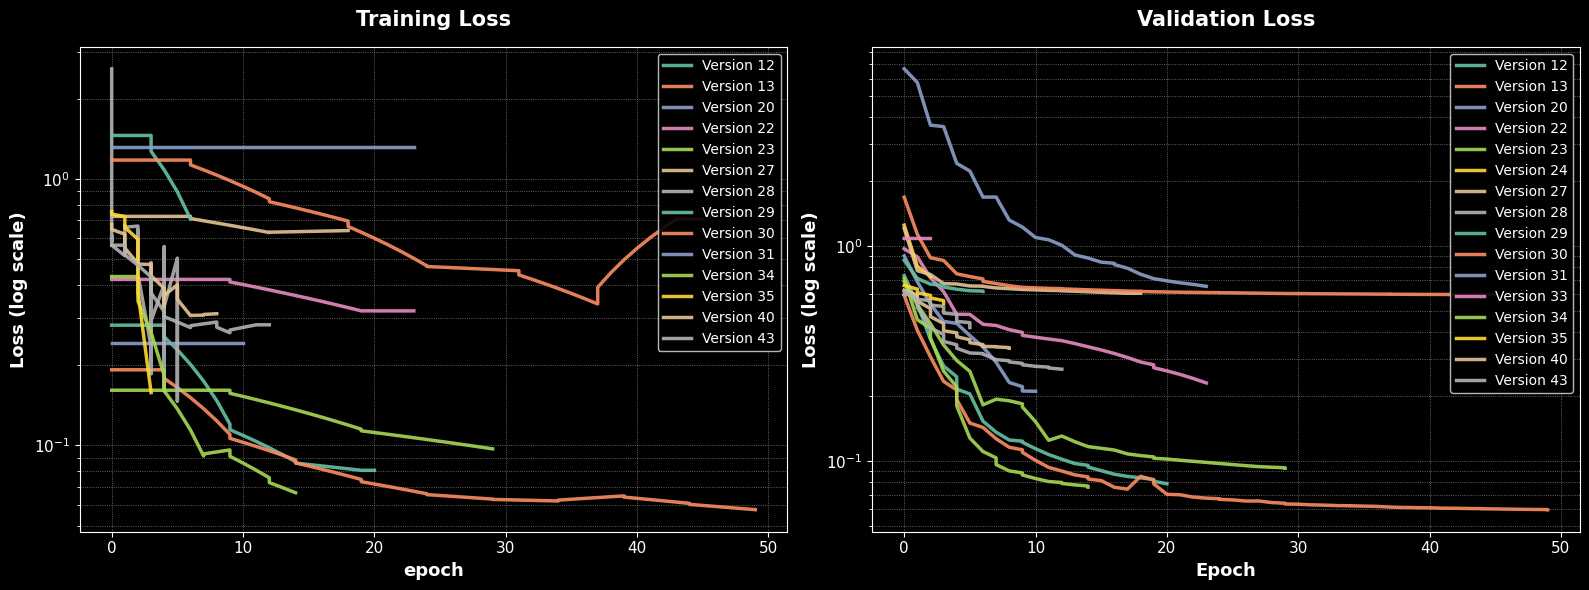

In [111]:
# Configuración de estilo
plt.style.use('dark_background')
COLORS = plt.cm.Set2.colors  # Paleta de colores más suave

def load_and_preprocess_metrics(logs_path):
    """Carga y preprocesa los archivos de métricas"""
    versions_folders = sorted(
        logs_path.glob('version_*'), 
        key=lambda x: int(x.name.split('_')[-1])
    )
    
    dfs = []
    version_nums = []
    
    for folder in versions_folders:
        metrics_file = folder / 'metrics.csv'
        try:
            df = pd.read_csv(metrics_file)
            
            # Ordenar por epoch si existe
            if 'epoch' in df.columns:
                df = df.sort_values('epoch').reset_index(drop=True)
            
            # Convertir losses a numérico e interpolar
            for col in ['train_loss', 'val_loss']:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            df = df.interpolate(method='linear', limit_direction='both')
            df = df.ffill().bfill()
            
            dfs.append(df)
            version_nums.append(int(folder.name.split('_')[-1]))
            
        except Exception as e:
            pass
    
    return dfs, version_nums

def plot_losses_separate(dfs, version_nums, figsize=(16, 6)):
    """Crea dos gráficas separadas: una para train y otra para val"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Gráfica de Training Loss
    for i, df in enumerate(dfs):
        if 'epoch' in df.columns and 'train_loss' in df.columns:
            color = COLORS[i % len(COLORS)]
            ax1.plot(
                df['epoch'], 
                df['train_loss'], 
                label=f'Version {version_nums[i]}',
                color=color,
                linewidth=2.5,
                alpha=0.9
            )
    
    ax1.set_yscale('log')
    ax1.set_xlabel('epoch', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Loss (log scale)', fontsize=13, fontweight='bold')
    ax1.set_title('Training Loss', fontsize=15, fontweight='bold', pad=15)
    ax1.legend(fontsize=10, loc='best', framealpha=0.9)
    ax1.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.5)
    ax1.tick_params(labelsize=11)
    
    # Gráfica de Validation Loss
    for i, df in enumerate(dfs):
        if 'epoch' in df.columns and 'val_loss' in df.columns:
            color = COLORS[i % len(COLORS)]
            ax2.plot(
                df['epoch'], 
                df['val_loss'], 
                label=f'Version {version_nums[i]}',
                color=color,
                linewidth=2.5,
                alpha=0.9
            )
    
    # ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Loss (log scale)', fontsize=13, fontweight='bold')
    ax2.set_title('Validation Loss', fontsize=15, fontweight='bold', pad=15)
    ax2.legend(fontsize=10, loc='best', framealpha=0.9)
    ax2.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.5)
    ax2.tick_params(labelsize=11)
    
    plt.tight_layout()
    return fig

dfs, version_nums = load_and_preprocess_metrics(logs_path)

# Opción 1: Gráficas lado a lado
fig = plot_losses_separate(dfs, version_nums)
plt.show()

# # Opción 2: Gráficas apiladas
# fig = plot_losses_stacked(dfs, version_nums)
# plt.show()

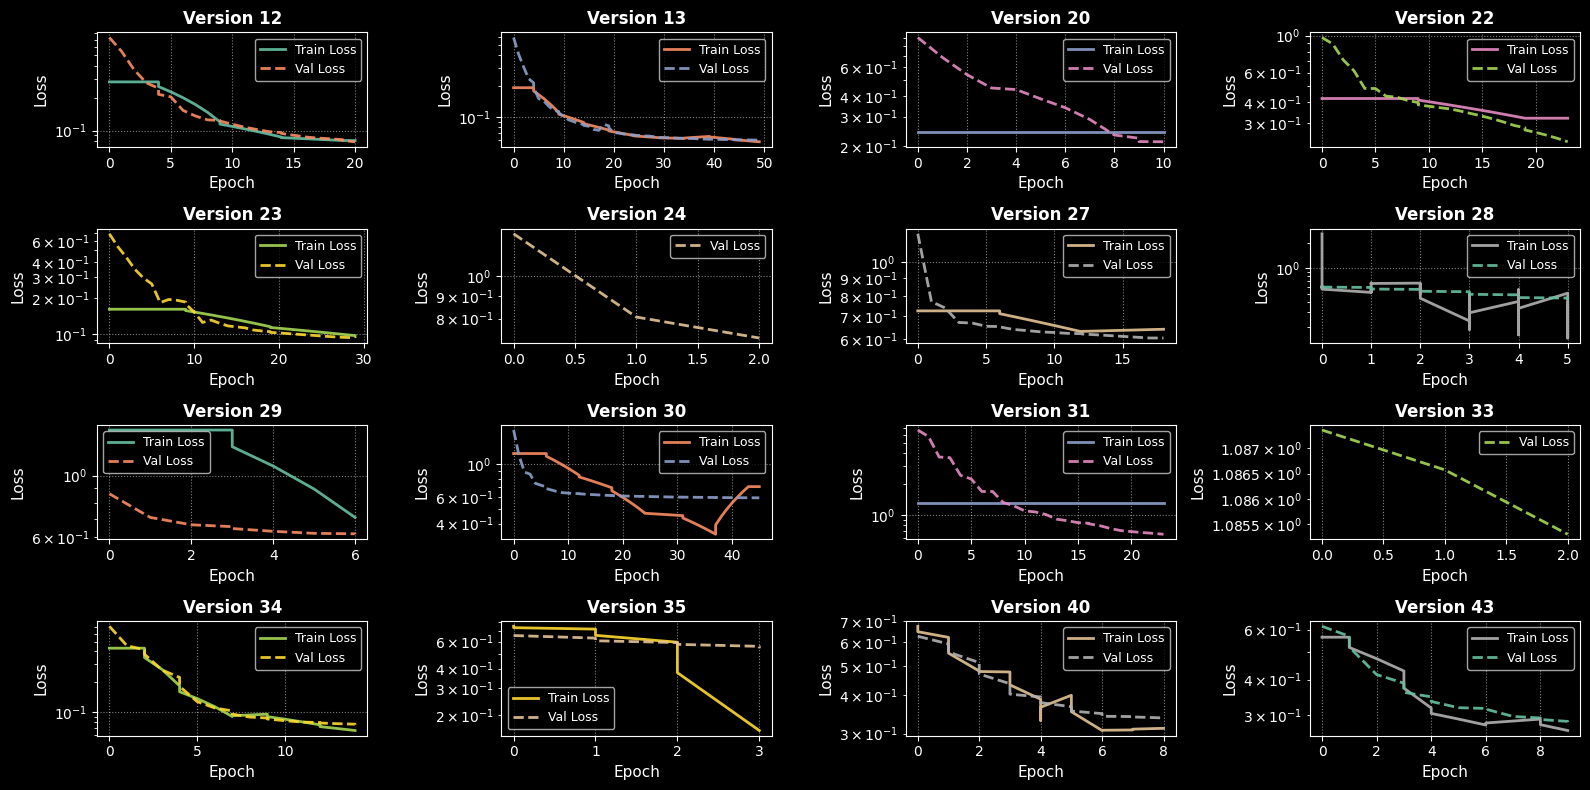

In [110]:
def plot_losses_vs_epochs(dfs, version_nums, figsize=(16, 8)):
    """Crea gráficas de train y validation loss vs epochs por versión"""
    
    num_versions = len(dfs)
    cols = 4  # Número de columnas para subplots
    rows = (num_versions + cols - 1) // cols  # Calcular filas necesarias
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if num_versions > 1 else [axes]
    
    for i, (df, version) in enumerate(zip(dfs, version_nums)):
        ax = axes[i]
        if 'epoch' in df.columns:
            if 'train_loss' in df.columns:
                ax.plot(df['epoch'], df['train_loss'], label='Train Loss', color=COLORS[i % len(COLORS)], linewidth=2, alpha=0.9)
            if 'val_loss' in df.columns:
                ax.plot(df['epoch'], df['val_loss'], label='Val Loss', color=COLORS[(i+1) % len(COLORS)], linewidth=2, alpha=0.9, linestyle='--')
            ax.set_xlabel('Epoch', fontsize=11)
            ax.set_ylabel('Loss', fontsize=11)
            ax.set_title(f'Version {version}', fontsize=12, fontweight='bold')
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.set_yscale('log')
        else:
            ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
    
    # Ocultar axes no usados
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    return fig

# Uso:
fig = plot_losses_vs_epochs(dfs, version_nums)
plt.show()